In [ ]:
# ==========================================================
# BAB IV
# Analisis Tren Fenologi Padi 2021–2025
# PART 1
# ==========================================================

import os
import glob
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 11

In [ ]:
# ==========================================================
# Membaca seluruh dataset
# ==========================================================

files = sorted(glob.glob("Fenologi_*_MODELLING*.csv"))

print("File ditemukan :")

for f in files:
    print("-", os.path.basename(f))

dfs = []

for f in files:

    tahun = int(os.path.basename(f).split("_")[1])

    temp = pd.read_csv(f)

    temp["Tahun"] = tahun

    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

print("\nJumlah data :", len(df))

File ditemukan :
- Fenologi_2021_MODELLING.csv
- Fenologi_2022_MODELLING.csv
- Fenologi_2023_MODELLING.csv
- Fenologi_2024_MODELLING.csv
- Fenologi_2025_MODELLING.csv

Jumlah data : 12789


In [ ]:
df["StartDate"] = pd.to_datetime(
    df["StartDate"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

df["EndDate"] = pd.to_datetime(
    df["EndDate"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

In [ ]:
# ==========================================================
# Variabel waktu
# ==========================================================

bulan = {

1:"Jan",
2:"Feb",
3:"Mar",
4:"Apr",
5:"Mei",
6:"Jun",
7:"Jul",
8:"Ags",
9:"Sep",
10:"Okt",
11:"Nov",
12:"Des"

}

df["Bulan"] = df["StartDate"].dt.month

df["Nama_Bulan"] = df["Bulan"].map(bulan)

df["Triwulan"] = ((df["Bulan"]-1)//3)+1

df["Semester"] = np.where(df["Bulan"]<=6,1,2)

In [ ]:
# ==========================================================
# Urutan fase
# ==========================================================

phase_order = [

"Flooding",
"EarlyVeg",
"Veg1",
"Veg2",
"Gen1",
"Gen2",
"Bare"

]

df["Phase"] = pd.Categorical(

    df["Phase"],
    categories=phase_order,
    ordered=True

)

In [ ]:
# ==========================================================
# Missing value
# ==========================================================

missing = pd.DataFrame({

"Missing":df.isna().sum(),

"Persen":round(df.isna().mean()*100,2)

})

display(missing)

,Missing,Persen
system:index,0,0.0
Desa,0,0.0
EndDate,0,0.0
HST_Fase_Kunjungan,0,0.0
HST_Lapangan,0,0.0
Kecamatan,0,0.0
Latitude,0,0.0
Longitude,0,0.0
NDRE,818,6.4
NDVI,818,6.4


In [ ]:
# ==========================================================
# Ringkasan Dataset
# ==========================================================

summary = (

    df.groupby("Tahun")
      .agg(

          Jumlah_Data=("OBJECTID","count"),

          Jumlah_Titik=("OBJECTID","nunique"),

          Kecamatan=("Kecamatan","nunique"),

          Desa=("Desa","nunique")

      )

)

display(summary)

,Jumlah_Data,Jumlah_Titik,Kecamatan,Desa
Tahun,,,,
2021,1953,279,22,156
2022,1071,153,19,105
2023,6209,887,29,272
2024,2338,334,24,152
2025,1218,174,12,88


In [ ]:
# ==========================================================
# Distribusi fase
# ==========================================================

fase = (

df

.groupby(["Tahun","Phase"])

.size()

.unstack(fill_value=0)

)

display(fase)

Phase,Flooding,EarlyVeg,Veg1,Veg2,Gen1,Gen2,Bare
Tahun,,,,,,,
2021,279,279,279,279,279,279,279
2022,153,153,153,153,153,153,153
2023,887,887,887,887,887,887,887
2024,334,334,334,334,334,334,334
2025,174,174,174,174,174,174,174


In [ ]:
# ==========================================================
# Statistik HST
# ==========================================================

hst = (

df

.groupby("Phase")[

"HST_Lapangan"

]

.describe()

)

display(hst)

,count,mean,std,min,25%,50%,75%,max
Phase,,,,,,,,
Flooding,1827.0,16.806263,13.149429,1.0,8.0,13.0,21.0,105.041667
EarlyVeg,1827.0,16.806263,13.149429,1.0,8.0,13.0,21.0,105.041667
Veg1,1827.0,16.806263,13.149429,1.0,8.0,13.0,21.0,105.041667
Veg2,1827.0,16.806263,13.149429,1.0,8.0,13.0,21.0,105.041667
Gen1,1827.0,16.806263,13.149429,1.0,8.0,13.0,21.0,105.041667
Gen2,1827.0,16.806263,13.149429,1.0,8.0,13.0,21.0,105.041667
Bare,1827.0,16.806263,13.149429,1.0,8.0,13.0,21.0,105.041667


In [ ]:
# ==========================================================
# Statistik Indeks
# ==========================================================

features = [

"NDVI",
"NDRE",
"VV",
"VH",
"RVI"

]

stats = (

df

.groupby("Phase")[features]

.describe()

)

display(stats)

NDVI                                                           \
           count         mean          std     min          25%       50%   
Phase                                                                       
Flooding  1699.0 -4384.299501  4963.161310 -9999.0 -9999.000000  0.149526   
EarlyVeg  1735.0 -4927.244206  5000.636062 -9999.0 -9999.000000  0.086793   
Veg1      1703.0 -3880.676179  4874.464092 -9999.0 -9999.000000  0.334260   
Veg2      1646.0 -3316.385289  4709.538653 -9999.0 -9999.000000  0.502353   
Gen1      1665.0 -3284.579295  4697.986547 -9999.0 -9999.000000  0.457051   
Gen2      1769.0 -2498.035172  4330.276106 -9999.0    -0.051736  0.327526   
Bare      1754.0 -4070.075782  4913.966282 -9999.0 -9999.000000  0.227684   

                                NDRE               ...         VH            \
               75%       max   count         mean  ...        75%       max   
Phase                                              ...                        
Flooding  0.350897  0.848869  1699.0 -4384.401198  ... -17.064678 -6.802709   
EarlyVeg  0.433692  0.863053  1735.0 -4927.342555  ... -16.663683 -6.077211   
Veg1      0.579187  0.928870  1703.0 -3880.798879  ... -15.997791 -4.327095   
Veg2      0.704600  0.910814  1646.0 -3316.515555  ... -15.515028 -6.638926   
Gen1      0.647224  0.953576  1665.0 -3284.710373  ... -14.992630 -4.025010   
Gen2      0.442298  0.891185  1769.0 -2498.161892  ... -14.740569 -8.467763   
Bare      0.378964  0.839483  1754.0 -4070.169053  ... -15.008647 -8.467763   

             RVI                                                        \
           count         mean          std     min       25%       50%   
Phase                                                                    
Flooding  1827.0 -1378.668897  3449.076503 -9999.0  0.250244  0.465313   
EarlyVeg  1827.0 -1887.675217  3914.678723 -9999.0  0.180242  0.436285   
Veg1      1827.0  -760.130400  2651.910768 -9999.0  0.364214  0.559296   
Veg2      1827.0  -382.362828  1920.017837 -9999.0  0.499275  0.728574   
Gen1      1827.0  -179.776879  1332.115187 -9999.0  0.604204  0.794561   
Gen2      1827.0  -688.861431  2534.592532 -9999.0  0.504589  0.714780   
Bare      1827.0 -1909.440117  3932.052244 -9999.0  0.259662  0.578022   

                              
               75%       max  
Phase                         
Flooding  0.708807  2.391984  
EarlyVeg  0.708949  2.494658  
Veg1      0.821961  2.110923  
Veg2      0.961222  2.374946  
Gen1      1.035319  2.199416  
Gen2      0.953286  2.721292  
Bare      0.882580  2.412592  

[7 rows x 40 columns]

In [ ]:
# ==========================================================
# Membuat folder output
# ==========================================================

os.makedirs("OUTPUT_BAB4",exist_ok=True)

summary.to_excel(

"OUTPUT_BAB4/Ringkasan_Dataset.xlsx"

)

fase.to_excel(

"OUTPUT_BAB4/Distribusi_Fase.xlsx"

)

missing.to_excel(

"OUTPUT_BAB4/Missing_Value.xlsx"

)

hst.to_excel(

"OUTPUT_BAB4/HST.xlsx"

)

stats.to_excel(

"OUTPUT_BAB4/Statistik_Indeks.xlsx"

)

print("Semua tabel berhasil disimpan.")

Semua tabel berhasil disimpan.


In [ ]:
# ==========================================================
# Folder Grafik
# ==========================================================

import os

os.makedirs("OUTPUT_BAB4/GRAFIK", exist_ok=True)

In [ ]:
# ==========================================================
# Warna Fase
# ==========================================================

phase_colors = {
    "Flooding": "#2E86DE",
    "EarlyVeg": "#F4D03F",
    "Veg1": "#7DCEA0",
    "Veg2": "#239B56",
    "Gen1": "#E74C3C",
    "Gen2": "#922B21",
    "Bare": "#8D6E63"
}

In [ ]:
# ==========================================================
# Distribusi Fase
# ==========================================================

distribusi = (
    df.groupby(['Tahun', 'Phase'])
      .size()
      .unstack(fill_value=0)
      .reset_index()
)

In [ ]:
# ==========================================================
# Flooding Bulanan
# ==========================================================

flood = (

df[df["Phase"]=="Flooding"]

.groupby(["Tahun","Bulan"])

.size()

.reset_index(name="Jumlah")

)

display(flood)

,Tahun,Bulan,Jumlah
0,2021,1,62
1,2021,3,2
2,2021,4,25
3,2021,5,41
4,2021,6,60
5,2021,7,24
6,2021,8,10
7,2021,9,3
8,2021,10,3
9,2021,11,2


In [ ]:
# ==========================================================
# Heatmap Flooding
# ==========================================================

heatmap = flood.pivot(

index="Tahun",

columns="Bulan",

values="Jumlah"

).fillna(0)

heatmap = heatmap.reindex(columns=range(1,13),fill_value=0)

heatmap.columns = [

"Jan","Feb","Mar","Apr","Mei","Jun",

"Jul","Ags","Sep","Okt","Nov","Des"

]

display(heatmap)

,Jan,Feb,Mar,Apr,Mei,Jun,Jul,Ags,Sep,Okt,Nov,Des
Tahun,,,,,,,,,,,,
2021,62.0,0.0,2.0,25.0,41.0,60.0,24.0,10.0,3.0,3.0,2.0,47.0
2022,0.0,0.0,0.0,8.0,27.0,19.0,45.0,2.0,0.0,1.0,9.0,42.0
2023,357.0,67.0,9.0,17.0,44.0,153.0,127.0,19.0,1.0,4.0,3.0,86.0
2024,59.0,48.0,13.0,4.0,18.0,59.0,47.0,43.0,0.0,1.0,14.0,28.0
2025,48.0,44.0,6.0,0.0,6.0,4.0,43.0,16.0,0.0,0.0,0.0,7.0


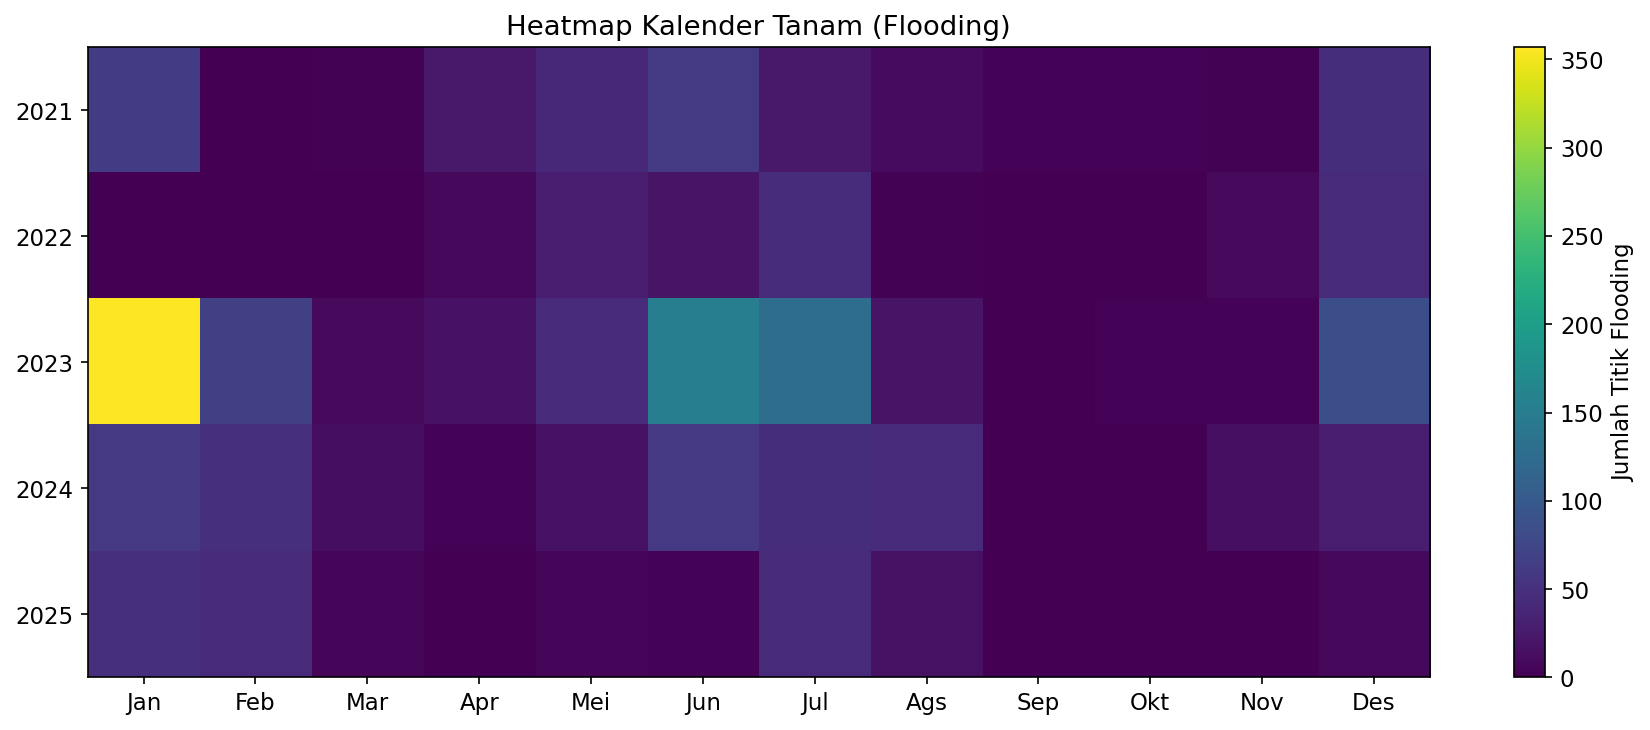

In [ ]:
# ==========================================================
# Heatmap
# ==========================================================

plt.figure(figsize=(12,5))

plt.imshow(

heatmap,

aspect="auto"

)

plt.xticks(

range(12),

heatmap.columns

)

plt.yticks(

range(len(heatmap.index)),

heatmap.index

)

plt.colorbar(

label="Jumlah Titik Flooding"

)

plt.title(

"Heatmap Kalender Tanam (Flooding)"

)

plt.tight_layout()

plt.savefig(

"OUTPUT_BAB4/GRAFIK/Heatmap_Kalender_Tanam.png"

)

plt.show()

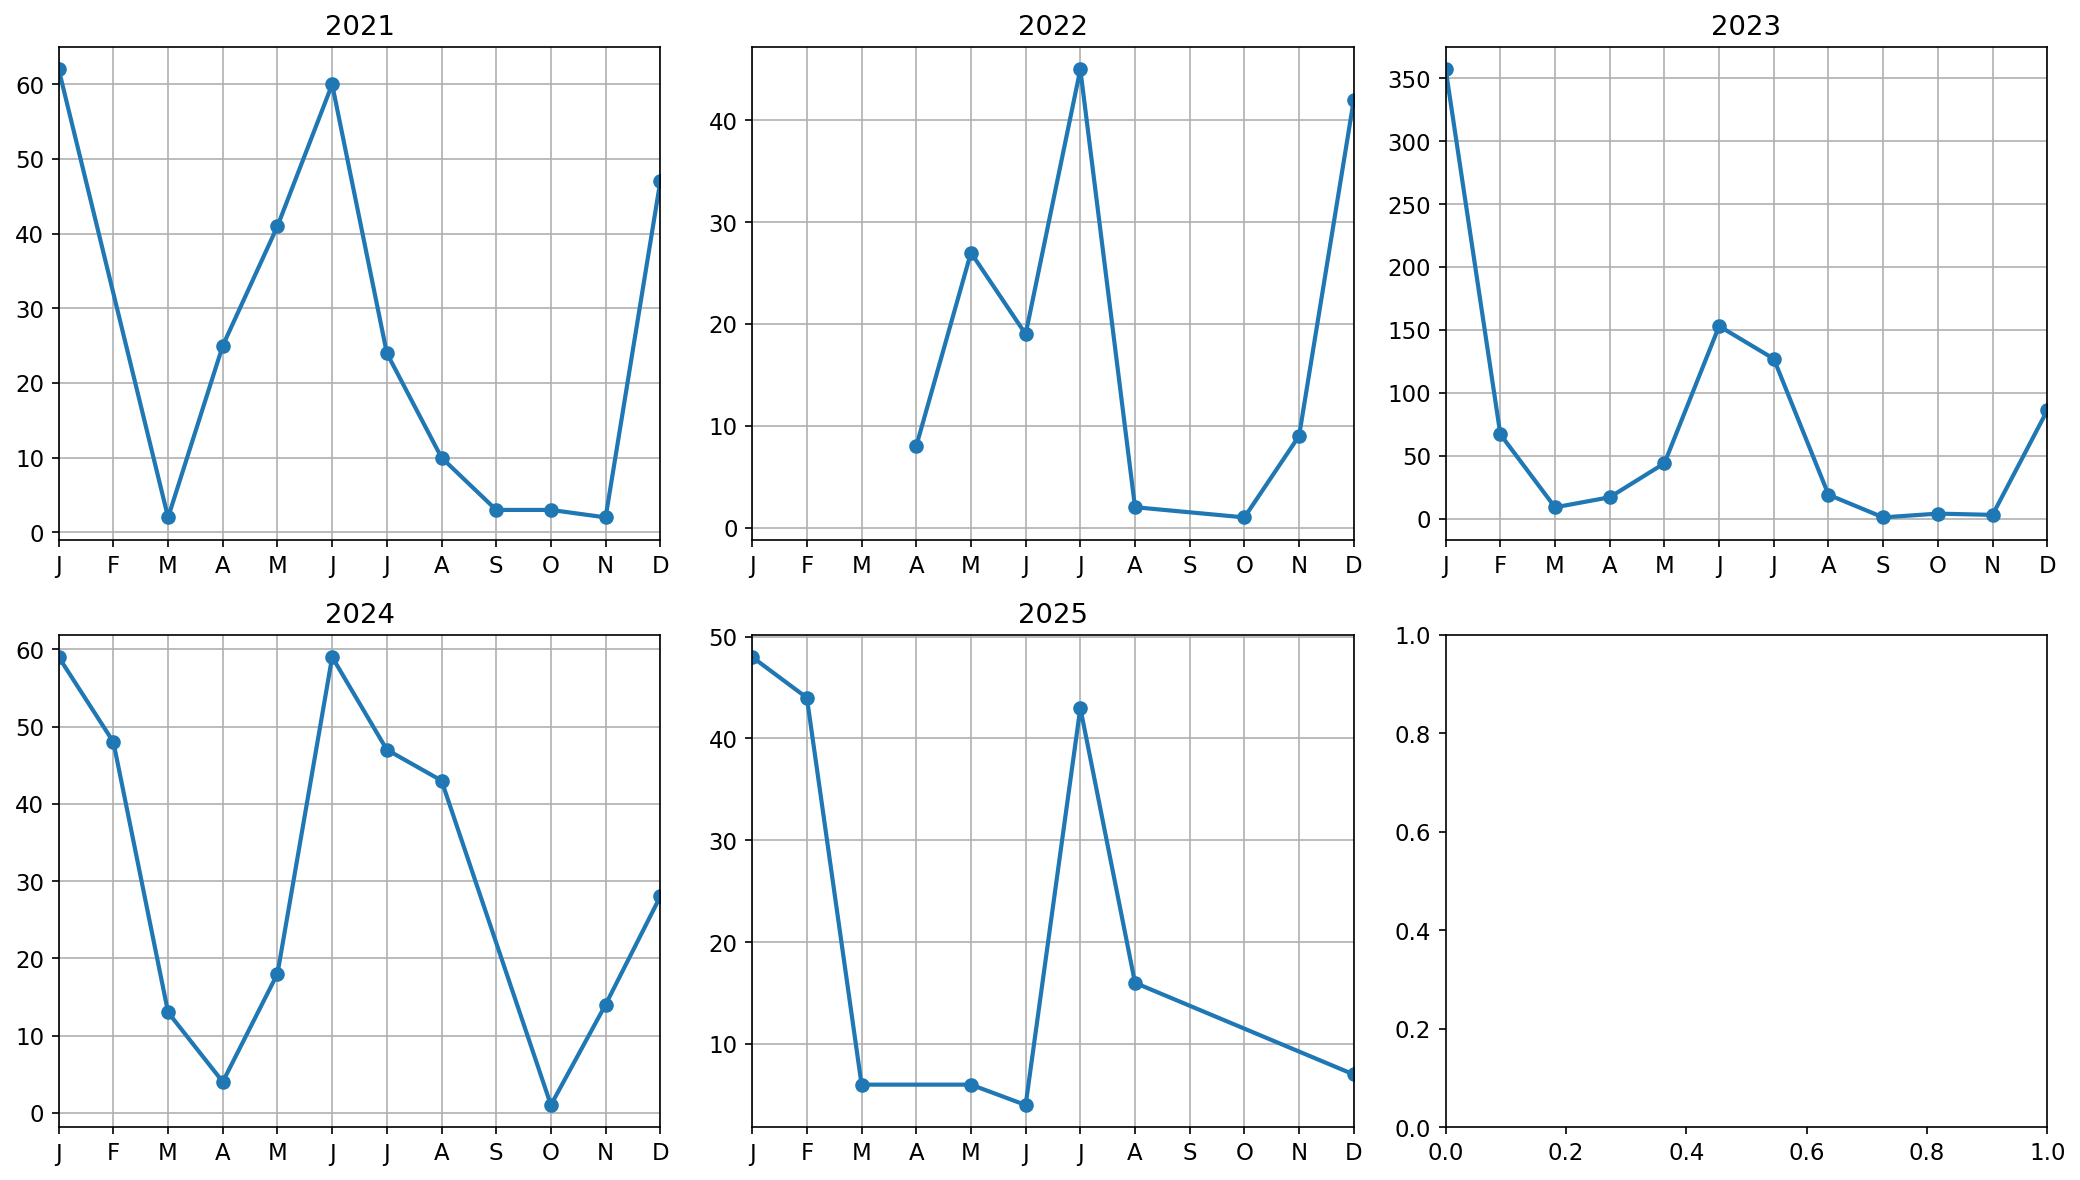

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(14, 8))
axs = axs.flatten()

bulan = ["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"]

for i, th in enumerate(sorted(df["Tahun"].unique())):

    tmp = flood[flood["Tahun"] == th]

    axs[i].plot(
        tmp["Bulan"],
        tmp["Jumlah"],
        marker="o",
        linewidth=2
    )

    axs[i].set_title(str(th))

    # Semua tahun menggunakan Januari–Desember
    axs[i].set_xlim(1, 12)
    axs[i].set_xticks(range(1, 13))
    axs[i].set_xticklabels(bulan)

    axs[i].grid(True)

plt.tight_layout()
plt.savefig("OUTPUT_BAB4/GRAFIK/Flooding_2020_2025.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# ==========================================================
# Bulan Dominan Flooding
# ==========================================================

idx = flood.groupby(

"Tahun"

)["Jumlah"].idxmax()

kalender = flood.loc[idx]

kalender["Nama_Bulan"] = kalender["Bulan"].map({

1:"Jan",

2:"Feb",

3:"Mar",

4:"Apr",

5:"Mei",

6:"Jun",

7:"Jul",

8:"Ags",

9:"Sep",

10:"Okt",

11:"Nov",

12:"Des"

})

display(kalender)

,Tahun,Bulan,Jumlah,Nama_Bulan
0,2021,1,62,Jan
14,2022,7,45,Jul
19,2023,1,357,Jan
31,2024,1,59,Jan
42,2025,1,48,Jan


In [ ]:
# ==========================================================
# Distribusi fase per bulan (2020-2025)
# ==========================================================

fase_bulan = (

    df
    .groupby(["Bulan","Phase"])
    .size()
    .unstack(fill_value=0)

)

fase_bulan = fase_bulan.reindex(
    columns=phase_order
)

display(fase_bulan)

Phase,Flooding,EarlyVeg,Veg1,Veg2,Gen1,Gen2,Bare
Bulan,,,,,,,
1,526,434,360,130,26,9,9
2,159,338,424,405,149,28,3
3,30,51,90,349,518,198,49
4,54,40,26,40,228,518,304
5,136,104,83,47,22,182,474
6,295,262,199,111,57,27,107
7,286,276,286,292,125,59,28
8,90,166,220,279,303,134,80
9,4,26,65,137,274,297,196


In [ ]:
# ==========================================================
# Persentase fase
# ==========================================================

fase_bulan_percent = round(

    fase_bulan.div(
        fase_bulan.sum(axis=1),
        axis=0
    )*100,

2

)

display(fase_bulan_percent)

Phase,Flooding,EarlyVeg,Veg1,Veg2,Gen1,Gen2,Bare
Bulan,,,,,,,
1,35.21,29.05,24.10,8.70,1.74,0.60,0.60
2,10.56,22.44,28.15,26.89,9.89,1.86,0.20
3,2.33,3.97,7.00,27.16,40.31,15.41,3.81
4,4.46,3.31,2.15,3.31,18.84,42.81,25.12
5,12.98,9.92,7.92,4.48,2.10,17.37,45.23
6,27.88,24.76,18.81,10.49,5.39,2.55,10.11
7,21.15,20.41,21.15,21.60,9.25,4.36,2.07
8,7.08,13.05,17.30,21.93,23.82,10.53,6.29
9,0.40,2.60,6.51,13.71,27.43,29.73,19.62


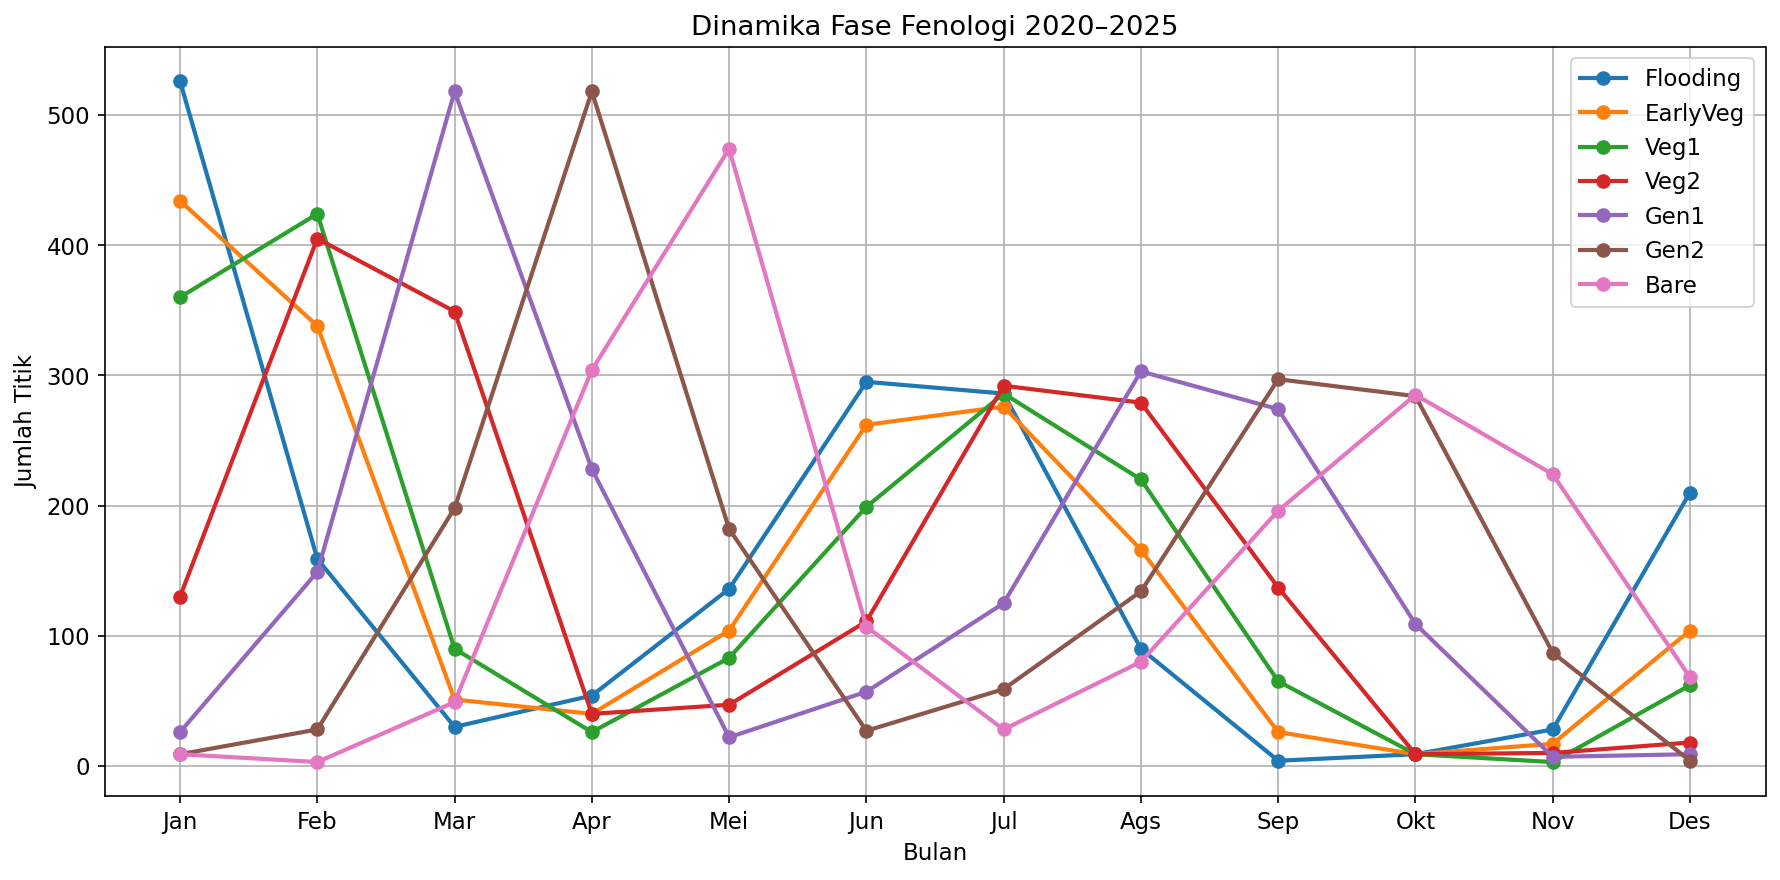

In [ ]:
# ==========================================================
# Grafik Dinamika Fenologi
# ==========================================================

plt.figure(figsize=(12,6))

for p in phase_order:

    plt.plot(

        fase_bulan.index,

        fase_bulan[p],

        marker="o",

        linewidth=2,

        label=p

    )

plt.xticks(range(1,13),

["Jan","Feb","Mar","Apr","Mei","Jun",

"Jul","Ags","Sep","Okt","Nov","Des"]

)

plt.grid(True)

plt.legend()

plt.title("Dinamika Fase Fenologi 2020–2025")

plt.xlabel("Bulan")

plt.ylabel("Jumlah Titik")

plt.tight_layout()

plt.savefig(

"OUTPUT_BAB4/GRAFIK/Dinamika_Fase.png"

)

plt.show()

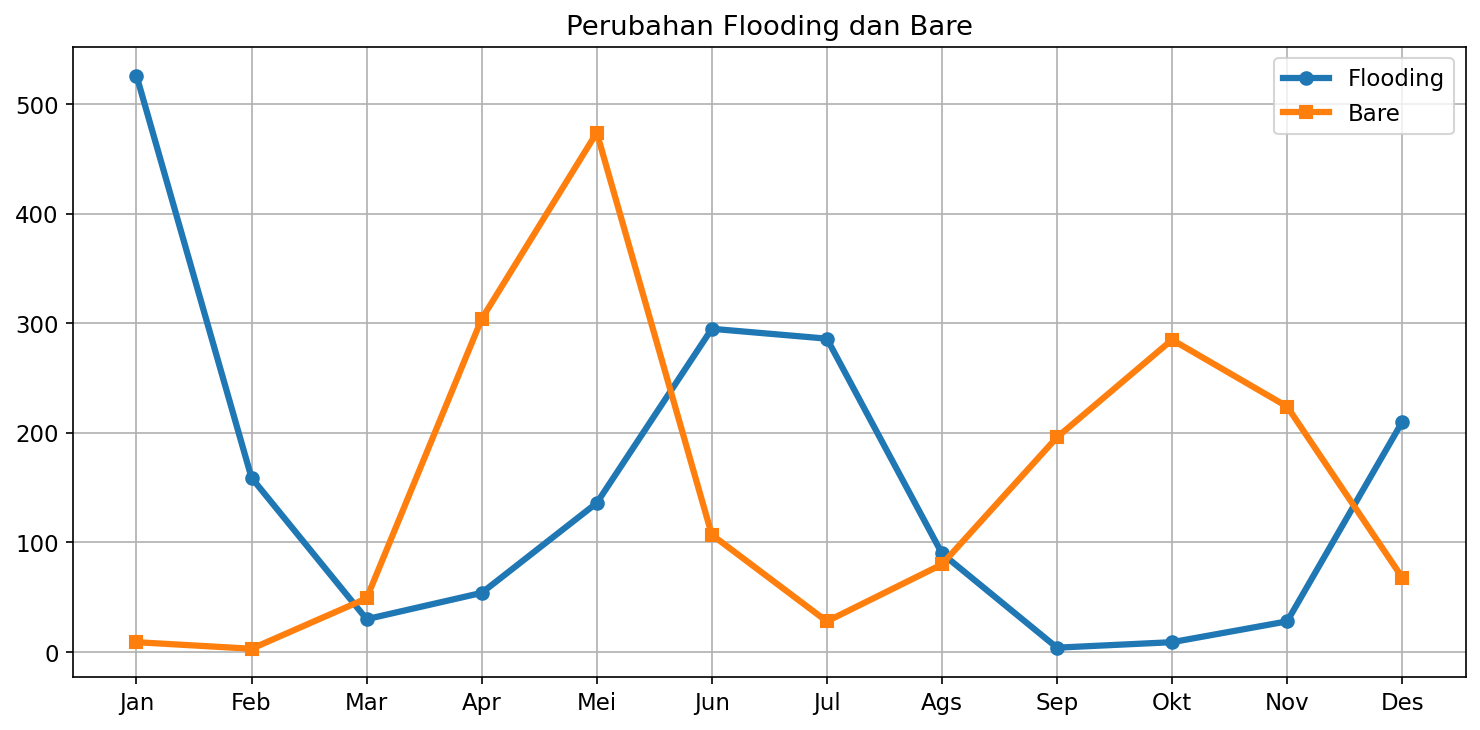

In [ ]:
# ==========================================================
# Flooding vs Bare
# ==========================================================

plt.figure(figsize=(10,5))

plt.plot(

fase_bulan.index,

fase_bulan["Flooding"],

marker="o",

linewidth=3,

label="Flooding"

)

plt.plot(

fase_bulan.index,

fase_bulan["Bare"],

marker="s",

linewidth=3,

label="Bare"

)

plt.xticks(

range(1,13),

["Jan","Feb","Mar","Apr","Mei","Jun",

"Jul","Ags","Sep","Okt","Nov","Des"]

)

plt.grid(True)

plt.legend()

plt.title("Perubahan Flooding dan Bare")

plt.tight_layout()

plt.savefig(

"OUTPUT_BAB4/GRAFIK/Flooding_vs_Bare.png"

)

plt.show()

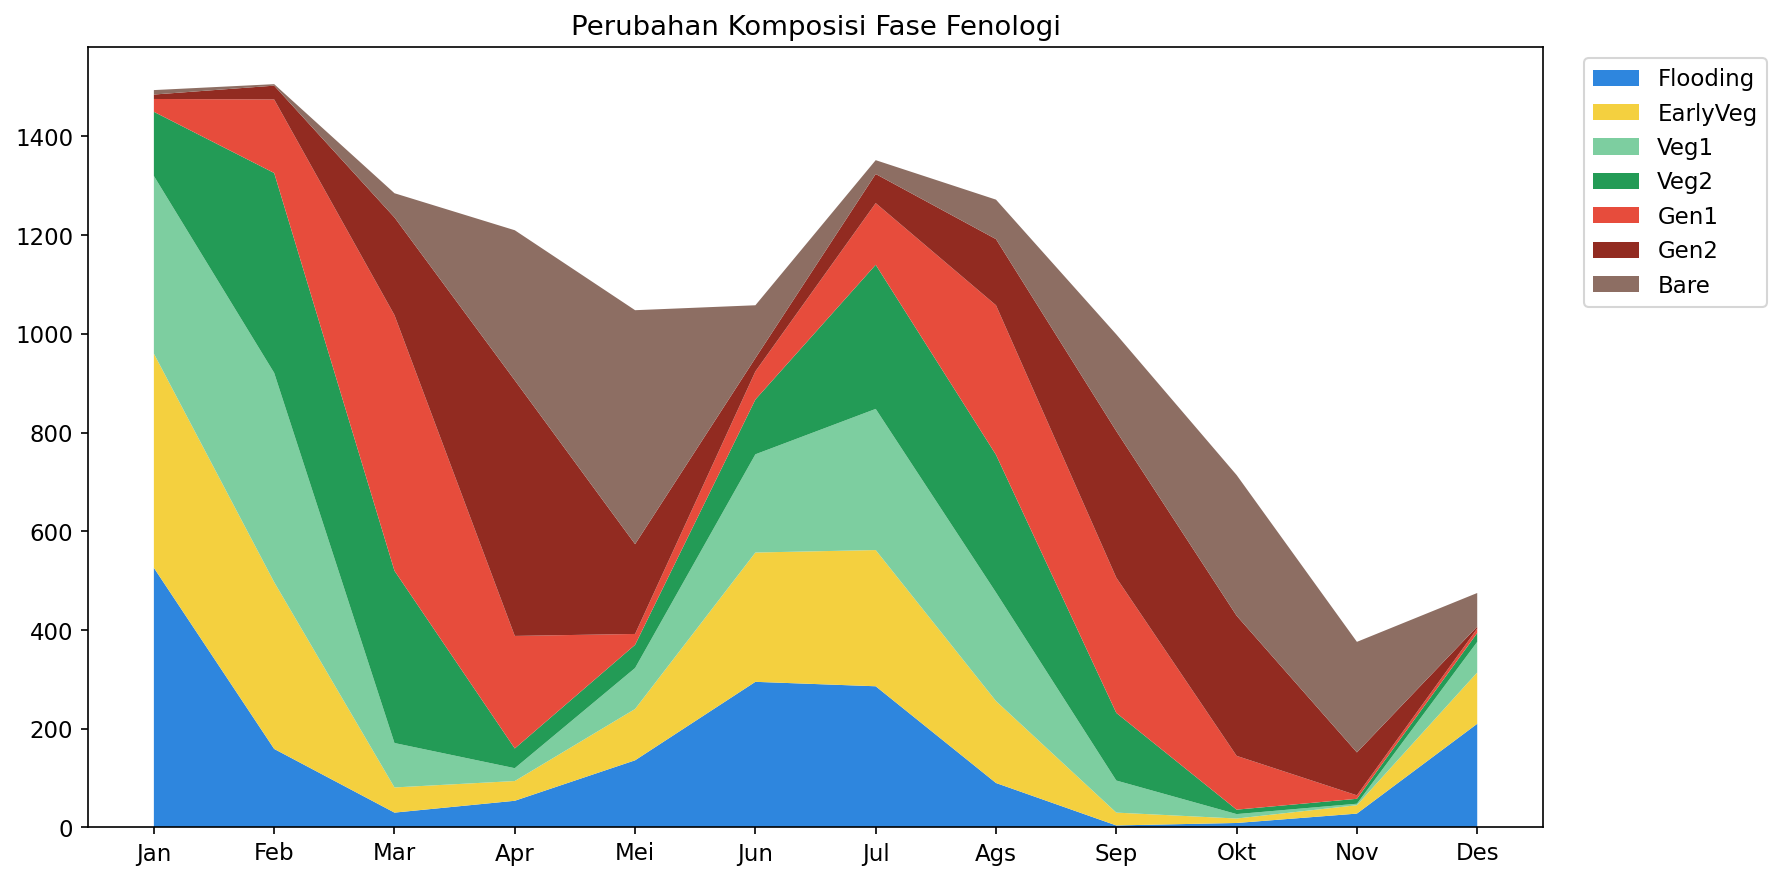

In [ ]:
# ==========================================================
# Area Chart
# ==========================================================

plt.figure(figsize=(12,6))

plt.stackplot(

fase_bulan.index,

[fase_bulan[c] for c in phase_order],

labels=phase_order,

colors=[phase_colors[c] for c in phase_order]

)

plt.xticks(

range(1,13),

["Jan","Feb","Mar","Apr","Mei","Jun",

"Jul","Ags","Sep","Okt","Nov","Des"]

)

plt.legend(

bbox_to_anchor=(1.02,1),

loc="upper left"

)

plt.title("Perubahan Komposisi Fase Fenologi")

plt.tight_layout()

plt.savefig(

"OUTPUT_BAB4/GRAFIK/Area_Fase.png"

)

plt.show()

In [ ]:
# ==========================================================
# Dominasi fase
# ==========================================================

dominasi = fase_bulan.idxmax(axis=1)

dominasi = pd.DataFrame({

"Bulan":dominasi.index,

"Fase_Dominan":dominasi.values,

"Jumlah":fase_bulan.max(axis=1).values

})

display(dominasi)

,Bulan,Fase_Dominan,Jumlah
0,1,Flooding,526
1,2,Veg1,424
2,3,Gen1,518
3,4,Gen2,518
4,5,Bare,474
5,6,Flooding,295
6,7,Veg2,292
7,8,Gen1,303
8,9,Gen2,297
9,10,Bare,285


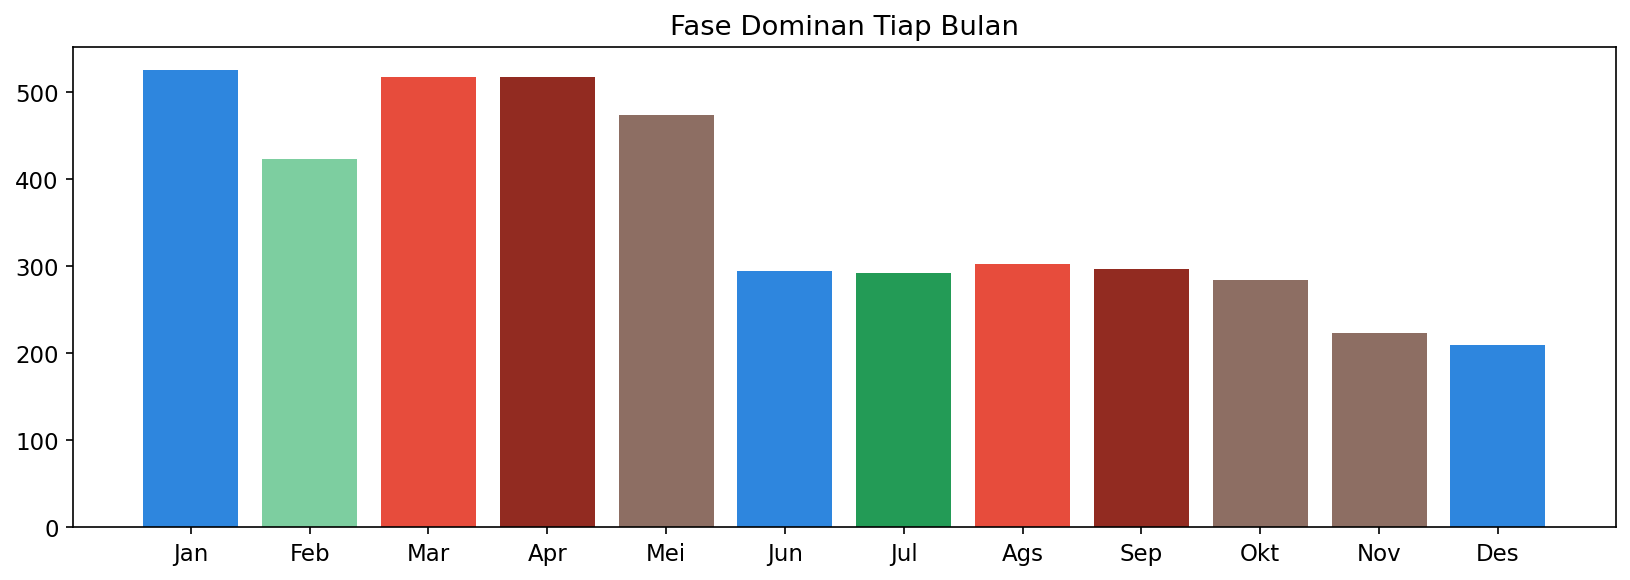

In [ ]:
# ==========================================================
# Dominasi fase
# ==========================================================

plt.figure(figsize=(11,4))

plt.bar(

dominasi["Bulan"],

dominasi["Jumlah"],

color=[

phase_colors[i]

for i in dominasi["Fase_Dominan"]

]

)

plt.xticks(

range(1,13),

["Jan","Feb","Mar","Apr","Mei","Jun",

"Jul","Ags","Sep","Okt","Nov","Des"]

)

plt.title("Fase Dominan Tiap Bulan")

plt.tight_layout()

plt.savefig(

"OUTPUT_BAB4/GRAFIK/Fase_Dominan.png"

)

plt.show()

In [ ]:
# ==========================================================
# Analisis September-Desember
# ==========================================================

akhir = fase_bulan.loc[9:12]

display(akhir)

Phase,Flooding,EarlyVeg,Veg1,Veg2,Gen1,Gen2,Bare
Bulan,,,,,,,
9,4,26,65,137,274,297,196
10,9,9,9,9,109,284,285
11,28,17,3,10,7,87,224
12,210,104,62,18,9,4,68


In [ ]:
# ==========================================================
# Export Excel
# ==========================================================

fase_bulan.to_excel(

"OUTPUT_BAB4/Fase_per_Bulan.xlsx"

)

fase_bulan_percent.to_excel(

"OUTPUT_BAB4/Persentase_Fase_per_Bulan.xlsx"

)

dominasi.to_excel(

"OUTPUT_BAB4/Fase_Dominan.xlsx",

index=False

)

print("Part 3 selesai.")

Part 3 selesai.


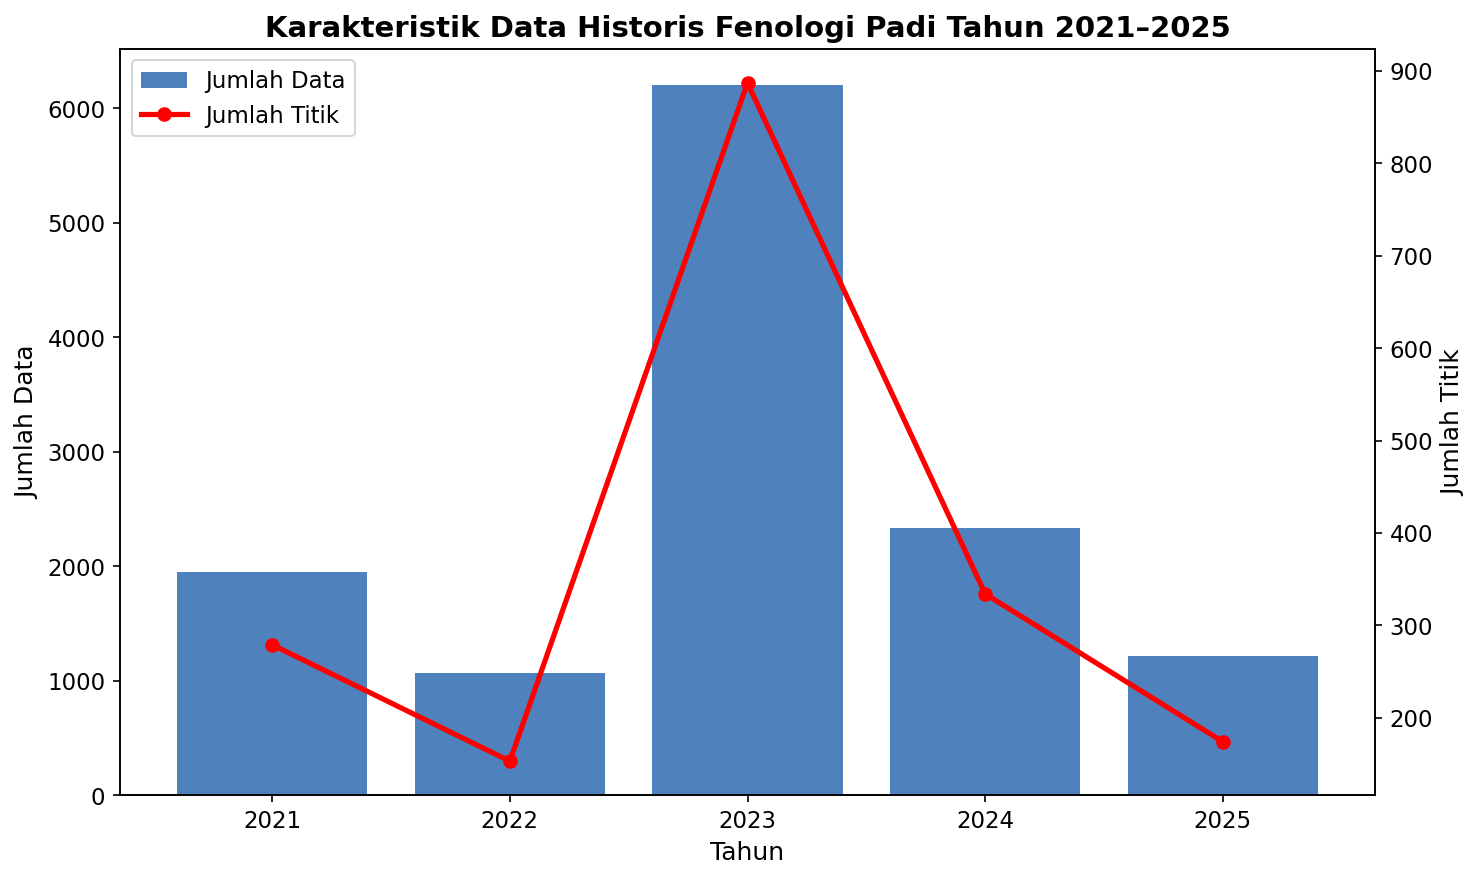

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ==========================
# Data
# ==========================
ringkasan = pd.DataFrame({
    "Tahun":[2021,2022,2023,2024,2025],
    "Jumlah_Data":[1953,1071,6209,2338,1218],
    "Jumlah_Titik":[279,153,887,334,174]
})

# ==========================
# Grafik
# ==========================

fig, ax1 = plt.subplots(figsize=(10,6))

# Bar jumlah data
ax1.bar(
    ringkasan["Tahun"].astype(str),
    ringkasan["Jumlah_Data"],
    color="#4F81BD",
    label="Jumlah Data"
)

ax1.set_ylabel("Jumlah Data", fontsize=12)
ax1.set_xlabel("Tahun", fontsize=12)

# Line jumlah titik
ax2 = ax1.twinx()

ax2.plot(
    ringkasan["Tahun"].astype(str),
    ringkasan["Jumlah_Titik"],
    color="red",
    marker="o",
    linewidth=2.5,
    label="Jumlah Titik"
)

ax2.set_ylabel("Jumlah Titik", fontsize=12)

plt.title(
    "Karakteristik Data Historis Fenologi Padi Tahun 2021–2025",
    fontsize=14,
    weight="bold"
)

# Gabung legenda
h1,l1=ax1.get_legend_handles_labels()
h2,l2=ax2.get_legend_handles_labels()

ax1.legend(h1+h2,l1+l2,loc="upper left")

plt.tight_layout()

plt.savefig(
    "Karakteristik_Data_Historis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import pandas as pd
import numpy as np
import glob
import os

bulan = {
    1:'Jan',2:'Feb',3:'Mar',4:'Apr',
    5:'Mei',6:'Jun',7:'Jul',8:'Ags',
    9:'Sep',10:'Okt',11:'Nov',12:'Des'
}

hasil=[]

files=sorted(glob.glob("/content/Fenologi_*_MODELLING.csv"))

for file in files:

    tahun=int(os.path.basename(file).split("_")[1])

    df=pd.read_csv(file)

    # hanya fase Flooding
    flood=df[df["Phase"]=="Flooding"].copy()

    flood["StartDate"]=pd.to_datetime(flood["StartDate"])

    flood["Bulan"]=flood["StartDate"].dt.month

    jumlah=flood.groupby("Bulan").size()

    jumlah=jumlah.reindex(range(1,13),fill_value=0)

    nilai=jumlah.values

    # threshold = 5% jumlah titik flooding
    threshold=max(5,int(0.05*len(flood)))

    peak=[]

    for i in range(12):

        kiri=nilai[i-1] if i>0 else 0
        kanan=nilai[i+1] if i<11 else 0

        if nilai[i]>=threshold:

            if nilai[i]>=kiri and nilai[i]>=kanan:

                peak.append(i+1)

    hasil.append({

        "Tahun":tahun,

        "Jumlah_Musim_Tanam":len(peak),

        "Awal_Musim_Tanam":", ".join([bulan[x] for x in peak])

    })

hasil=pd.DataFrame(hasil)

display(hasil)

hasil.to_excel(
    "Jumlah_Musim_Tanam.xlsx",
    index=False
)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    hasil["Tahun"].astype(str),
    hasil["Jumlah_Musim_Tanam"],
    edgecolor="black"
)

for i,v in enumerate(hasil["Jumlah_Musim_Tanam"]):
    plt.text(i,v+0.05,str(v),ha='center')

plt.ylim(0,max(hasil["Jumlah_Musim_Tanam"])+1)

plt.ylabel("Jumlah Musim Tanam")

plt.xlabel("Tahun")

plt.title("Jumlah Musim Tanam Tahun 2020–2025")

plt.grid(axis='y',alpha=0.3)

plt.tight_layout()

plt.savefig(
    "Jumlah_Musim_Tanam.png",
    dpi=300
)

plt.show()

In [ ]:
import pandas as pd

# ==========================
# BACA DATA
# ==========================
df = pd.read_csv("/content/MASTER_PETA_FENOLOGI_2025_15HARI.csv")

# ==========================
# JUMLAH SETIAP FASE
# ==========================
rekap = (
    df.groupby(["Periode", "Phase_Final"])
      .size()
      .unstack(fill_value=0)
)

# urutkan kolom
urutan = [
    "Flooding",
    "EarlyVeg",
    "Veg1",
    "Veg2",
    "Gen1",
    "Gen2",
    "Bare"
]

rekap = rekap.reindex(columns=urutan, fill_value=0)

display(rekap)

rekap.to_excel(
    "Tabel_Dinamika_Fase.xlsx"
)

In [ ]:
# ==========================
# FASE DOMINAN
# ==========================

dominan = rekap.idxmax(axis=1)

jumlah = rekap.max(axis=1)

tabel = pd.DataFrame({

    "Periode":dominan.index,

    "Fase_Dominan":dominan.values,

    "Jumlah":jumlah.values

})

display(tabel)

tabel.to_excel(
    "Fase_Dominan.xlsx",
    index=False
)

In [ ]:
import matplotlib.pyplot as plt

# Ambil hanya periode 1-16 (Jan P1 - Agustus P2)
rekap_plot = rekap.loc[1:16]

plt.figure(figsize=(14,6))

warna = {
    "Flooding":"dodgerblue",
    "EarlyVeg":"gold",
    "Veg1":"limegreen",
    "Veg2":"green",
    "Gen1":"orange",
    "Gen2":"red",
    "Bare":"gray"
}

for fase in urutan:
    plt.plot(
        rekap_plot.index,
        rekap_plot[fase],
        marker="o",
        linewidth=2,
        label=fase,
        color=warna[fase]
    )

# Label periode
label_periode = [
    "Jan P1","Jan P2",
    "Feb P1","Feb P2",
    "Mar P1","Mar P2",
    "Apr P1","Apr P2",
    "Mei P1","Mei P2",
    "Jun P1","Jun P2",
    "Jul P1","Jul P2",
    "Agu P1","Agu P2"
]

plt.xticks(rekap_plot.index, label_periode, rotation=45)

plt.xlabel("Periode Pengamatan")
plt.ylabel("Jumlah Titik")
plt.title(
    "Dinamika Fase Fenologi Padi Tahun 2025 (Januari–Agustus)",
    fontsize=14,
    weight="bold"
)

plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "Grafik_Dinamika_Fase_Jan_Agustus.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
persen = rekap.div(
    rekap.sum(axis=1),
    axis=0
)*100

display(persen.round(2))

persen.to_excel(
    "Persentase_Fase_2025.xlsx"
)

In [ ]:
plt.figure(figsize=(14,6))

plt.stackplot(

    rekap.index,

    [rekap[f] for f in urutan],

    labels=urutan,

    colors=[
        "dodgerblue",
        "gold",
        "limegreen",
        "green",
        "orange",
        "red",
        "gray"
    ]

)

plt.xticks(range(1,25))

plt.xlabel("Periode (15 Hari)")

plt.ylabel("Jumlah Titik")

plt.title(

    "Perubahan Komposisi Fase Fenologi Tahun 2025",

    fontsize=14,

    weight="bold"

)

plt.legend(loc="upper left")

plt.tight_layout()

plt.savefig(

    "Area_Dinamika_Fase.png",

    dpi=300

)

plt.show()